In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [39]:
import sys
import os
from pathlib import Path

# Deteksi Lingkungan (Colab vs Lokal)
if 'google.colab' in str(get_ipython()):
    print("Berjalan di Google Colab")
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path("/content/drive/MyDrive/PROJECTS/fb-intelligence")
else:
    print("Berjalan di Komputer Lokal")
    current_dir = Path.cwd()
    PROJECT_ROOT = current_dir.parent if current_dir.name == "notebooks" else current_dir

# Registrasikan Root Project ke Python Path & Ubah Working Directory
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)

# Path Data
DATA_DIR = PROJECT_ROOT / "data" / "raw"

print("Project root  :", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

Berjalan di Komputer Lokal
Project root  : d:\Project\Python\Machine-Learning\fb-intelligence
Data directory: d:\Project\Python\Machine-Learning\fb-intelligence\data\raw


In [3]:
# Load Data
demand = pd.read_csv(DATA_DIR / "daily_demand.csv", parse_dates=["date"])
weather = pd.read_csv(DATA_DIR / "weather.csv", parse_dates=["date"])
promotions = pd.read_csv(DATA_DIR / "promotions.csv", parse_dates=["date"])
holidays = pd.read_csv(DATA_DIR / "holidays.csv", parse_dates=["date"])

print("Demand:", demand.shape)
print("Weather:", weather.shape)
print("Promotions:", promotions.shape)
print("Holidays:", holidays.shape)

Demand: (365500, 10)
Weather: (7310, 5)
Promotions: (48, 6)
Holidays: (8, 2)


In [4]:
demand.head()

,date,branch_id,product_id,quantity,temperature,rainfall,discount_percentage,is_weekend,is_payday,is_holiday
0,2024-01-01,B001,P001,20,28.9,0.0,0.0,False,False,True
1,2024-01-01,B001,P002,24,28.9,0.0,0.0,False,False,True
2,2024-01-01,B001,P003,52,28.9,0.0,0.0,False,False,True
3,2024-01-01,B001,P004,77,28.9,0.0,0.0,False,False,True
4,2024-01-01,B001,P005,81,28.9,0.0,0.0,False,False,True


In [5]:
demand.info()

<class 'pandas.DataFrame'>
RangeIndex: 365500 entries, 0 to 365499
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   date                 365500 non-null  datetime64[us]
 1   branch_id            365500 non-null  str           
 2   product_id           365500 non-null  str           
 3   quantity             365500 non-null  int64         
 4   temperature          365500 non-null  float64       
 5   rainfall             365500 non-null  float64       
 6   discount_percentage  365500 non-null  float64       
 7   is_weekend           365500 non-null  bool          
 8   is_payday            365500 non-null  bool          
 9   is_holiday           365500 non-null  bool          
dtypes: bool(3), datetime64[us](1), float64(3), int64(1), str(2)
memory usage: 20.6 MB


In [6]:
demand.describe()

,date,quantity,temperature,rainfall,discount_percentage
count,365500,365500.000000,365500.000000,365500.000000,365500.000000
mean,2024-12-30 23:59:59.999999,64.382534,27.984338,2.148175,0.002230
min,2024-01-01 00:00:00,1.000000,21.710000,0.000000,0.000000
25%,2024-07-01 00:00:00,37.000000,26.690000,0.000000,0.000000
50%,2024-12-31 00:00:00,59.000000,27.960000,0.000000,0.000000
75%,2025-07-02 00:00:00,85.000000,29.240000,2.780000,0.000000
max,2025-12-31 00:00:00,396.000000,34.150000,46.230000,25.000000
std,NaN,35.173456,1.851449,4.157616,0.204419


In [7]:
daily_total = (
    demand
    .groupby("date", as_index=False)
    .agg(
        total_demand=("quantity", "sum"),
    )
)

daily_total.head()

,date,total_demand
0,2024-01-01,31024
1,2024-01-02,25746
2,2024-01-03,25183
3,2024-01-04,25089
4,2024-01-05,24969


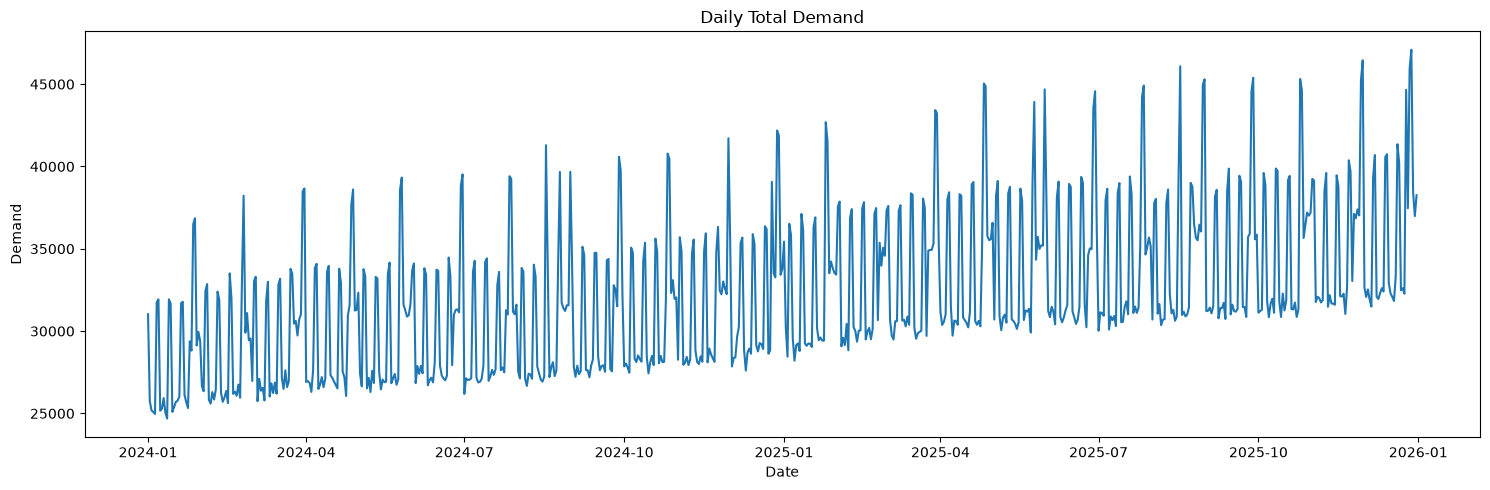

In [8]:
plt.figure(figsize=(15, 5))

plt.plot(
    daily_total["date"],
    daily_total["total_demand"],
)

plt.title("Daily Total Demand")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

In [9]:
demand["day_of_week"] = demand["date"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

dow_stats = (
    demand
    .groupby("day_of_week")["quantity"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        total="sum",
    )
    .reindex(weekday_order)
)

dow_stats

,mean,median,std,total
day_of_week,,,,
Monday,60.083067,55.0,32.180611,3154361
Tuesday,59.921619,55.0,32.035045,3145885
Wednesday,60.305924,55.0,32.193969,3166061
Thursday,60.352058,55.0,32.243388,3138307
Friday,60.042385,55.0,32.081708,3122204
Saturday,74.987115,69.0,39.664238,3899330
Sunday,75.109000,69.0,40.096100,3905668


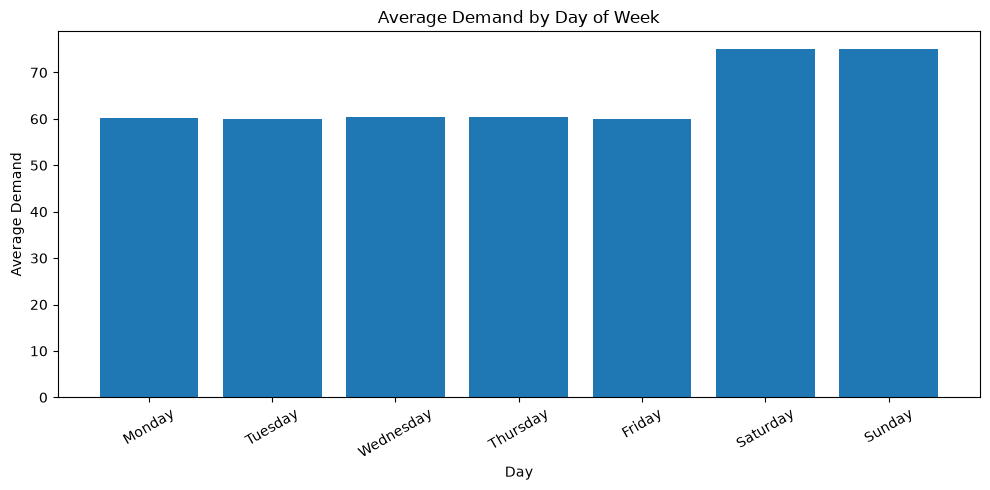

In [10]:
plt.figure(figsize=(10, 5))

plt.bar(
    dow_stats.index,
    dow_stats["mean"],
)

plt.title("Average Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Demand")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [11]:
demand["month"] = demand["date"].dt.month

monthly_stats = (
    demand
    .groupby("month")["quantity"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        total="sum",
    )
)

monthly_stats

,mean,median,std,total
month,,,,
1,60.602871,55.0,33.140209,1878689
2,61.250491,56.0,33.260865,1745639
3,63.457323,58.0,34.701279,1967177
4,63.406833,57.0,34.832861,1902205
5,64.125258,58.0,35.231009,1987883
6,64.598400,59.0,35.249856,1937952
7,63.907194,58.0,34.841872,1981123
8,65.429710,60.0,35.698771,2028321
9,65.069267,59.0,35.130134,1952078


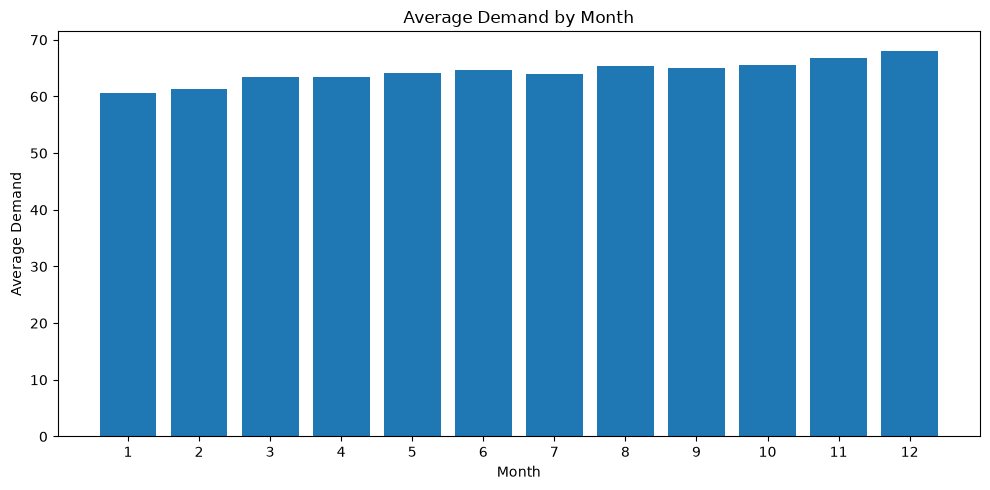

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(
    monthly_stats.index,
    monthly_stats["mean"],
)

plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [13]:
demand["year"] = demand["date"].dt.year

monthly_yearly = (
    demand
    .groupby(
        ["year", "month"]
    )["quantity"]
    .mean()
    .reset_index()
)

monthly_yearly

,year,month,quantity
0,2024,1,56.386710
1,2024,2,57.263172
2,2024,3,59.333484
3,2024,4,59.190867
4,2024,5,59.761548
5,2024,6,60.745600
6,2024,7,59.869290
7,2024,8,61.026129
8,2024,9,61.515067
9,2024,10,61.824258


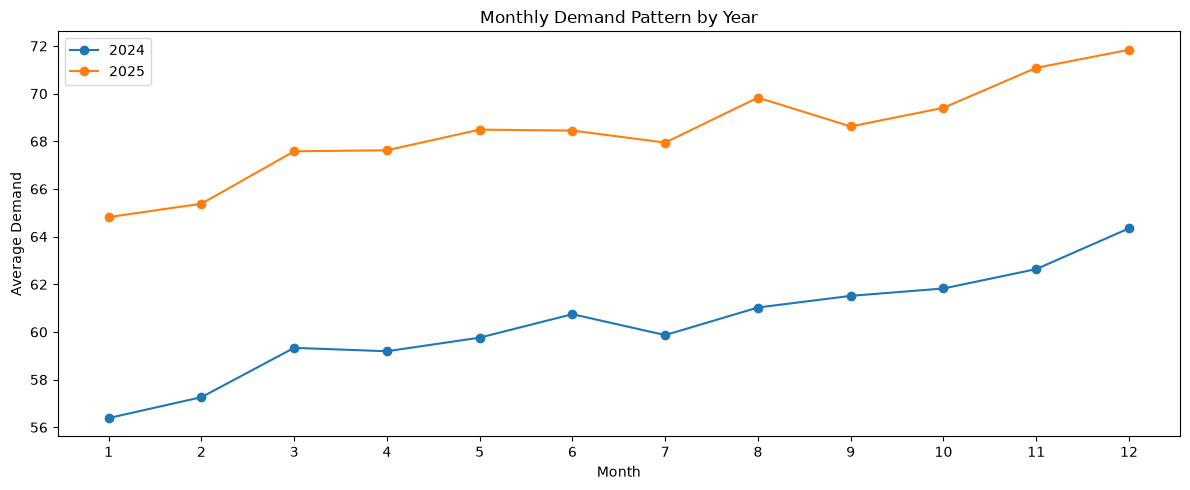

In [14]:
plt.figure(figsize=(12, 5))

for year in sorted(
    monthly_yearly["year"].unique()
):
    subset = monthly_yearly[
        monthly_yearly["year"] == year
    ]

    plt.plot(
        subset["month"],
        subset["quantity"],
        marker="o",
        label=str(year),
    )

plt.title("Monthly Demand Pattern by Year")
plt.xlabel("Month")
plt.ylabel("Average Demand")
plt.xticks(range(1, 13))
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
holiday_stats = (
    demand
    .groupby("is_holiday")["quantity"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        total="sum",
        count="count",
    )
)

holiday_stats

,mean,median,std,total,count
is_holiday,,,,,
False,64.247129,58.0,35.078380,23225337,361500
True,76.619750,70.0,41.107507,306479,4000


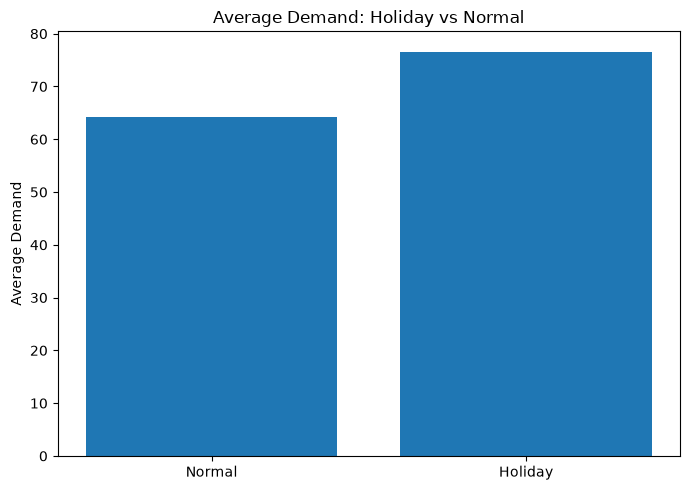

In [16]:
plt.figure(figsize=(7, 5))

labels = [
    "Normal",
    "Holiday",
]

values = [
    holiday_stats.loc[False, "mean"],
    holiday_stats.loc[True, "mean"],
]

plt.bar(
    labels,
    values,
)

plt.title("Average Demand: Holiday vs Normal")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

In [17]:
payday_stats = (
    demand
    .groupby("is_payday")["quantity"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        total="sum",
        count="count",
    )
)

payday_stats

,mean,median,std,total,count
is_payday,,,,,
False,62.329083,57.0,33.774643,17950776,288000
True,72.013419,66.0,39.008901,5581040,77500


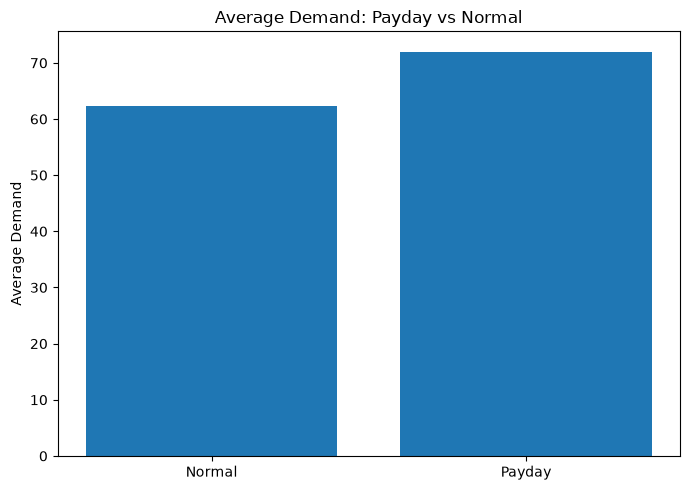

In [18]:
plt.figure(figsize=(7, 5))

labels = [
    "Normal",
    "Payday",
]

values = [
    payday_stats.loc[False, "mean"],
    payday_stats.loc[True, "mean"],
]

plt.bar(
    labels,
    values,
)

plt.title("Average Demand: Payday vs Normal")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

In [19]:
demand["is_promotion"] = (
    demand["discount_percentage"] > 0
)

promotion_stats = (
    demand
    .groupby("is_promotion")["quantity"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        total="sum",
        count="count",
    )
)

promotion_stats

,mean,median,std,total,count
is_promotion,,,,,
False,64.381134,59.0,35.172905,23528214,365452
True,75.041667,69.5,38.063753,3602,48


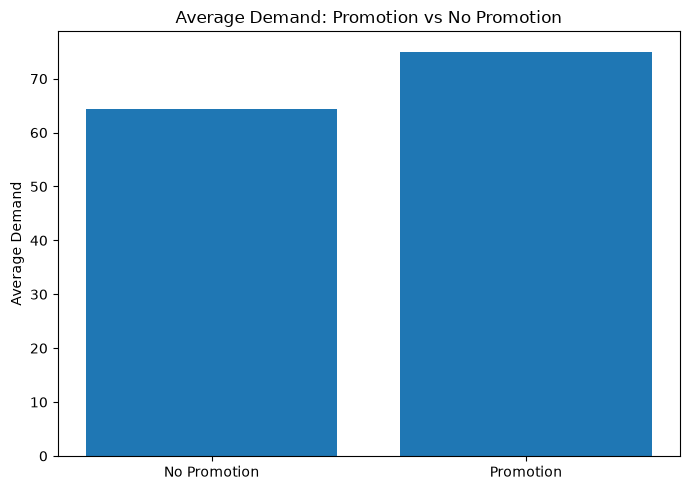

In [20]:
plt.figure(figsize=(7, 5))

labels = [
    "No Promotion",
    "Promotion",
]

values = [
    promotion_stats.loc[False, "mean"],
    promotion_stats.loc[True, "mean"],
]

plt.bar(
    labels,
    values,
)

plt.title("Average Demand: Promotion vs No Promotion")
plt.ylabel("Average Demand")

plt.tight_layout()
plt.show()

In [21]:
daily_weather_demand = (
    demand
    .groupby("date", as_index=False)
    .agg(
        demand=("quantity", "sum"),
        temperature=("temperature", "mean"),
        rainfall=("rainfall", "mean"),
    )
)

daily_weather_demand.head()

,date,demand,temperature,rainfall
0,2024-01-01,31024,28.277,1.975
1,2024-01-02,25746,28.057,7.635
2,2024-01-03,25183,28.036,2.248
3,2024-01-04,25089,28.078,1.867
4,2024-01-05,24969,28.118,5.075


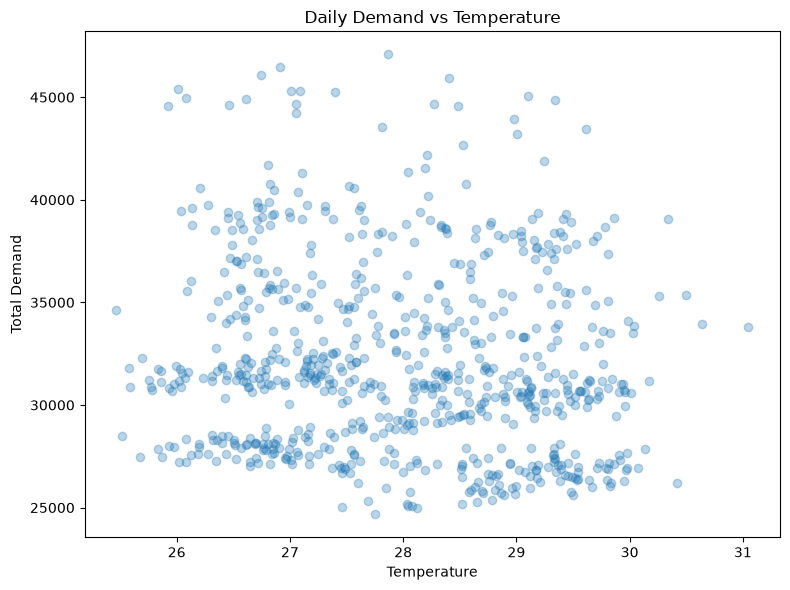

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    daily_weather_demand["temperature"],
    daily_weather_demand["demand"],
    alpha=0.3,
)

plt.title("Daily Demand vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Total Demand")

plt.tight_layout()
plt.show()

In [23]:
products = pd.read_csv(
    DATA_DIR / "products.csv"
)

demand_product = demand.merge(
    products[
        [
            "product_id",
            "category",
        ]
    ],
    on="product_id",
    how="left",
)

beverage = demand_product[
    demand_product["category"] == "Beverage"
].copy()

In [24]:
beverage_weather = (
    beverage
    .groupby("date", as_index=False)
    .agg(
        demand=("quantity", "sum"),
        temperature=("temperature", "mean"),
    )
)

beverage_weather.corr(
    numeric_only=True
)

,demand,temperature
demand,1.000000,0.107237
temperature,0.107237,1.000000


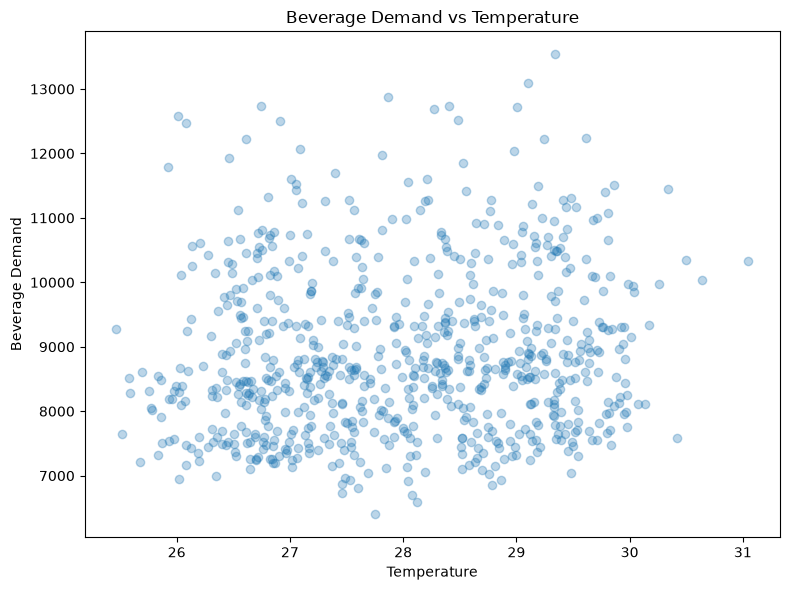

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(
    beverage_weather["temperature"],
    beverage_weather["demand"],
    alpha=0.3,
)

plt.title("Beverage Demand vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Beverage Demand")

plt.tight_layout()
plt.show()

In [26]:
weekday_avg = demand.loc[
    ~demand["is_weekend"],
    "quantity",
].mean()

weekend_avg = demand.loc[
    demand["is_weekend"],
    "quantity",
].mean()

normal_payday_avg = demand.loc[
    ~demand["is_payday"],
    "quantity",
].mean()

payday_avg = demand.loc[
    demand["is_payday"],
    "quantity",
].mean()

normal_holiday_avg = demand.loc[
    ~demand["is_holiday"],
    "quantity",
].mean()

holiday_avg = demand.loc[
    demand["is_holiday"],
    "quantity",
].mean()

normal_promo_avg = demand.loc[
    ~demand["is_promotion"],
    "quantity",
].mean()

promo_avg = demand.loc[
    demand["is_promotion"],
    "quantity",
].mean()

print("=" * 60)
print("EDA FORECASTING SUMMARY")
print("=" * 60)

print(
    f"Date range       : "
    f"{demand['date'].min().date()} → "
    f"{demand['date'].max().date()}"
)

print(
    f"Mean daily demand: "
    f"{daily_total['total_demand'].mean():.2f}"
)

print(
    f"Weekend uplift   : "
    f"{(weekend_avg / weekday_avg - 1) * 100:.2f}%"
)

print(
    f"Payday uplift    : "
    f"{(payday_avg / normal_payday_avg - 1) * 100:.2f}%"
)

print(
    f"Holiday uplift   : "
    f"{(holiday_avg / normal_holiday_avg - 1) * 100:.2f}%"
)

print(
    f"Promo uplift     : "
    f"{(promo_avg / normal_promo_avg - 1) * 100:.2f}%"
)

EDA FORECASTING SUMMARY
Date range       : 2024-01-01 → 2025-12-31
Mean daily demand: 32191.27
Weekend uplift   : 24.79%
Payday uplift    : 15.54%
Holiday uplift   : 19.26%
Promo uplift     : 16.56%


Product demand statistics

In [27]:
product_stats = (
    demand
    .groupby("product_id")["quantity"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        total="sum",
    )
    .sort_values("total", ascending=False)
)

product_stats.head(10)

,mean,median,std,min,max,total
product_id,,,,,,
P024,106.467989,101.0,36.792046,24,338,778281
P030,102.536525,98.0,35.876736,20,396,749542
P014,102.311765,97.0,35.870555,27,308,747899
P005,99.861970,95.0,34.202734,24,287,729991
P041,98.330917,94.0,33.403212,20,269,718799
P009,95.999316,92.0,32.398047,20,255,701755
P027,95.785226,91.0,32.862123,25,263,700190
P004,94.213406,90.0,31.974159,24,272,688700
P042,93.463885,89.0,32.828718,23,268,683221


Top 10 products

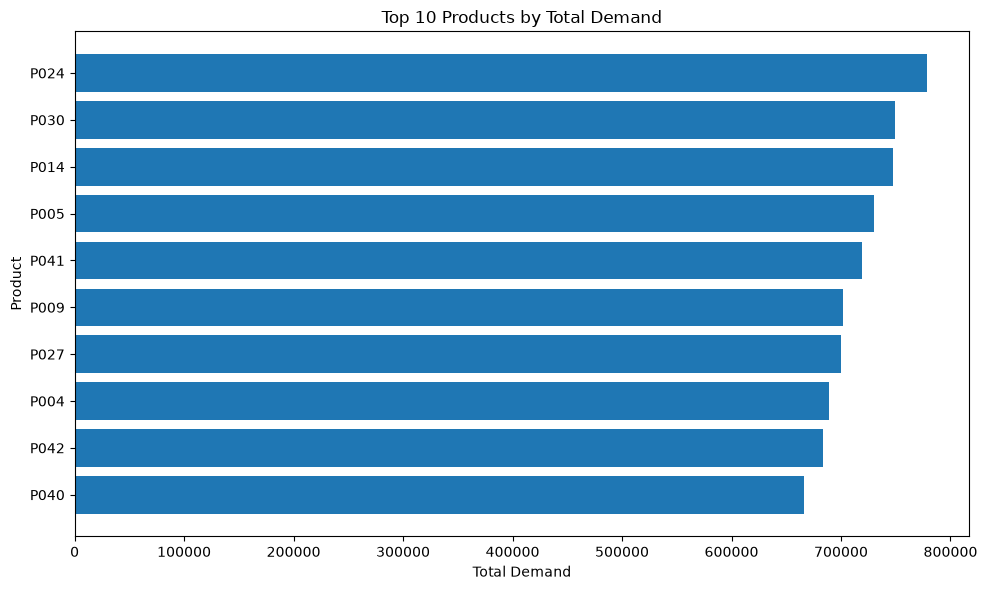

In [28]:
top_products = (
    product_stats
    .head(10)
    .sort_values("total")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products.index,
    top_products["total"],
)

plt.title("Top 10 Products by Total Demand")
plt.xlabel("Total Demand")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [29]:
product_stats["cv"] = (
    product_stats["std"]
    / product_stats["mean"]
)

product_stats.sort_values(
    "cv",
    ascending=False
).head(10)

,mean,median,std,min,max,total,cv
product_id,,,,,,,
P020,20.683447,20.0,8.036886,2,62,151196,0.388566
P039,22.439945,21.0,8.667646,2,70,164036,0.386260
P026,24.279070,23.0,9.361126,4,68,177480,0.385564
P047,22.771409,22.0,8.762873,1,70,166459,0.384819
P017,28.870178,27.0,10.854892,4,82,211041,0.375990
P029,33.332285,32.0,12.403850,5,113,243659,0.372127
P015,28.127633,27.0,10.443575,4,79,205613,0.371292
P001,32.213817,31.0,11.945324,6,102,235483,0.370814
P022,50.632969,48.0,18.670037,9,161,370127,0.368733


Most volatile products

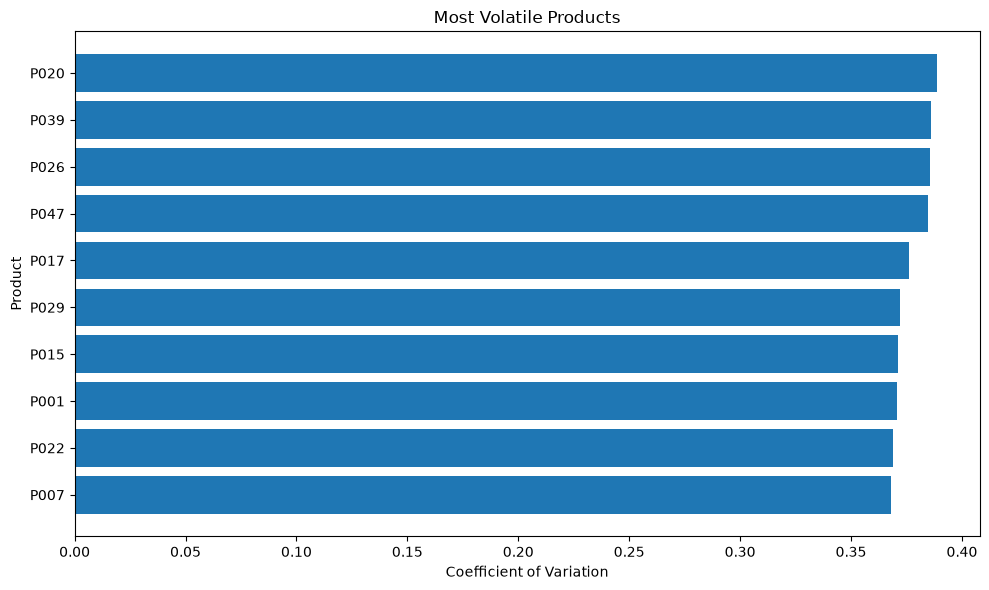

In [30]:
volatile_products = (
    product_stats
    .sort_values("cv", ascending=False)
    .head(10)
    .sort_values("cv")
)

plt.figure(figsize=(10, 6))

plt.barh(
    volatile_products.index,
    volatile_products["cv"],
)

plt.title("Most Volatile Products")
plt.xlabel("Coefficient of Variation")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

Branch Analysis

In [31]:
branch_stats = (
    demand
    .groupby("branch_id")["quantity"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        total="sum",
    )
    .sort_values("total", ascending=False)
)

branch_stats

,mean,median,std,min,max,total
branch_id,,,,,,
B010,81.907168,77.0,40.665951,4,396,2993707
B009,78.895103,74.0,39.117028,4,308,2883616
B005,75.372640,71.0,37.363163,2,338,2754870
B002,70.811847,67.0,35.191942,5,270,2588173
B006,70.739425,67.0,35.065074,3,293,2585526
B004,69.104104,65.0,34.402251,5,311,2525755
B001,52.261833,49.0,26.151252,3,192,1910170
B003,51.694555,49.0,25.877202,3,201,1889436
B007,46.692777,44.0,23.464288,2,205,1706621


Branch demand

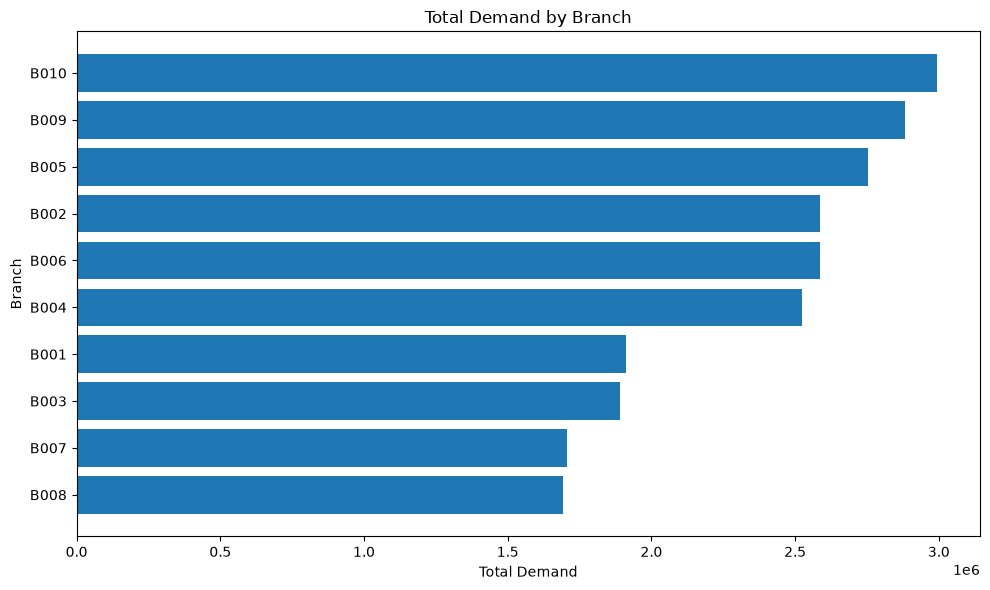

In [32]:
plt.figure(figsize=(10, 6))

branch_plot = (
    branch_stats
    .sort_values("total")
)

plt.barh(
    branch_plot.index,
    branch_plot["total"],
)

plt.title("Total Demand by Branch")
plt.xlabel("Total Demand")
plt.ylabel("Branch")

plt.tight_layout()
plt.show()

In [33]:
product_branch = (
    demand
    .groupby(
        [
            "branch_id",
            "product_id",
        ]
    )["quantity"]
    .mean()
    .reset_index()
)

product_branch.head()

,branch_id,product_id,quantity
0,B001,P001,25.831737
1,B001,P002,45.254446
2,B001,P003,63.414501
3,B001,P004,76.614227
4,B001,P005,79.703146


In [34]:
heatmap_data = (
    product_branch
    .pivot(
        index="product_id",
        columns="branch_id",
        values="quantity",
    )
)

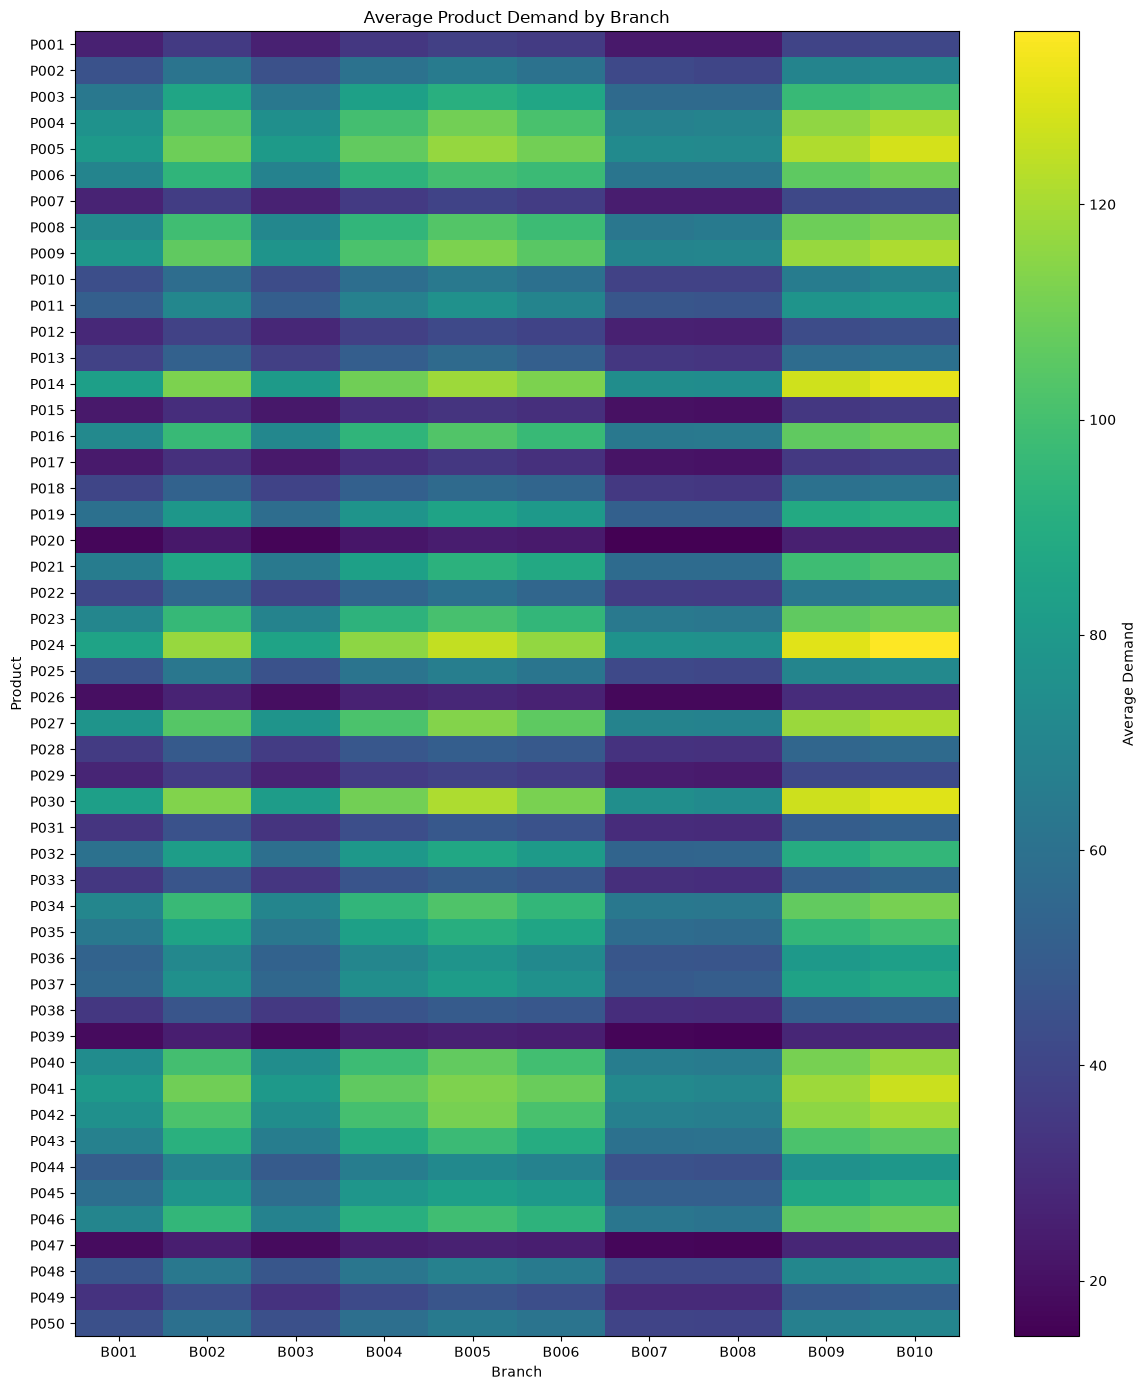

In [35]:
plt.figure(figsize=(12, 14))

plt.imshow(
    heatmap_data,
    aspect="auto",
)

plt.colorbar(
    label="Average Demand"
)

plt.title(
    "Average Product Demand by Branch"
)

plt.xlabel("Branch")
plt.ylabel("Product")

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index,
)

plt.tight_layout()
plt.show()

total demand harian

In [36]:
forecast_series = (
    demand
    .groupby("date")["quantity"]
    .sum()
    .sort_index()
)

In [37]:
lag_correlations = {}

for lag in [
    1,
    2,
    3,
    7,
    14,
    21,
    28,
]:
    lag_correlations[lag] = (
        forecast_series
        .corr(
            forecast_series.shift(lag)
        )
    )

pd.Series(
    lag_correlations,
    name="correlation"
)

1     0.553255
2     0.140620
3     0.119405
7     0.747750
14    0.744660
21    0.739935
28    0.887032
Name: correlation, dtype: float64

In [40]:
from src.features.forecasting import (
    create_forecasting_dataset,
)

forecasting_df = create_forecasting_dataset(
    demand
)

print(
    forecasting_df.shape
)

forecasting_df.head()

(351500, 23)


,date,branch_id,product_id,quantity,discount_percentage,is_payday,is_holiday,day_of_week,day_of_month,month,...,lag_7,lag_14,lag_21,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_28,rolling_std_28
0,2024-01-29,B001,P001,24,0.0,1,0,0,29,1,...,23.0,25.0,22.0,20.0,25.000000,12.096832,22.857143,8.725358,22.785714,7.314912
1,2024-01-30,B001,P001,32,0.0,1,0,1,30,1,...,25.0,21.0,26.0,22.0,25.142857,12.075161,22.785714,8.710547,22.928571,7.297532
2,2024-01-31,B001,P001,15,0.0,1,0,2,31,1,...,11.0,18.0,18.0,22.0,26.142857,12.348125,23.571429,9.027431,23.285714,7.492501
3,2024-02-01,B001,P001,19,0.0,0,0,3,1,2,...,23.0,19.0,15.0,23.0,26.714286,11.600493,23.357143,9.203738,23.035714,7.652074
4,2024-02-02,B001,P001,25,0.0,0,0,4,2,2,...,25.0,18.0,23.0,19.0,26.142857,11.908380,23.357143,9.203738,22.892857,7.690009


In [41]:
forecasting_df[
    [
        "date",
        "branch_id",
        "product_id",
        "quantity",
        "lag_1",
        "lag_7",
        "lag_14",
        "lag_21",
        "lag_28",
        "rolling_mean_7",
        "rolling_mean_14",
        "rolling_mean_28",
    ]
].head(20)

,date,branch_id,product_id,quantity,lag_1,lag_7,lag_14,lag_21,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28
0,2024-01-29,B001,P001,24,18.0,23.0,25.0,22.0,20.0,25.000000,22.857143,22.785714
1,2024-01-30,B001,P001,32,24.0,25.0,21.0,26.0,22.0,25.142857,22.785714,22.928571
2,2024-01-31,B001,P001,15,32.0,11.0,18.0,18.0,22.0,26.142857,23.571429,23.285714
3,2024-02-01,B001,P001,19,15.0,23.0,19.0,15.0,23.0,26.714286,23.357143,23.035714
4,2024-02-02,B001,P001,25,19.0,25.0,18.0,23.0,19.0,26.142857,23.357143,22.892857
5,2024-02-03,B001,P001,16,25.0,50.0,20.0,21.0,24.0,26.142857,23.857143,23.107143
6,2024-02-04,B001,P001,22,16.0,18.0,24.0,41.0,22.0,21.285714,23.571429,22.821429
7,2024-02-05,B001,P001,19,22.0,24.0,23.0,25.0,22.0,21.857143,23.428571,22.821429
8,2024-02-06,B001,P001,14,19.0,32.0,25.0,21.0,26.0,21.142857,23.142857,22.714286
9,2024-02-07,B001,P001,15,14.0,15.0,11.0,18.0,18.0,18.571429,22.357143,22.285714


In [42]:
feature_columns = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_21",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_14",
    "rolling_std_28",
]

leakage_check = (
    forecasting_df[feature_columns]
    .isna()
    .sum()
)

print(leakage_check)

lag_1              0
lag_7              0
lag_14             0
lag_21             0
lag_28             0
rolling_mean_7     0
rolling_mean_14    0
rolling_mean_28    0
rolling_std_7      0
rolling_std_14     0
rolling_std_28     0
dtype: int64


In [43]:
example = (
    forecasting_df[
        (
            forecasting_df["branch_id"] == "B010"
        )
        &
        (
            forecasting_df["product_id"] == "P024"
        )
    ]
    .sort_values("date")
)

example[
    [
        "date",
        "quantity",
        "lag_1",
        "lag_7",
        "lag_28",
    ]
].head(10)

,date,quantity,lag_1,lag_7,lag_28
332519,2024-01-29,87,189.0,108.0,90.0
332520,2024-01-30,188,87.0,131.0,72.0
332521,2024-01-31,149,188.0,90.0,85.0
332522,2024-02-01,73,149.0,95.0,154.0
332523,2024-02-02,109,73.0,96.0,96.0
332524,2024-02-03,157,109.0,137.0,163.0
332525,2024-02-04,160,157.0,189.0,124.0
332526,2024-02-05,93,160.0,87.0,86.0
332527,2024-02-06,125,93.0,188.0,108.0
332528,2024-02-07,126,125.0,149.0,145.0
